# **Student** **Academic** **Performance** **Analysis**

## Exploratory Data Analysis (EDA) of Student Academic Performance

### Introduction

Student performance is influenced by several academic and non-academic factors, including study habits, attendance, extracurricular activities, and personal characteristics. Understanding how these factors relate to academic achievement can provide valuable insights into students' learning patterns.

This project performs an exploratory data analysis (EDA) on a student performance dataset using **Pandas** for data manipulation and **Matplotlib** for data visualization. The analysis aims to identify patterns, compare student groups, and examine relationships between different variables that may influence overall academic performance.

### Objectives

The objectives of this analysis are to:

- Explore the structure and quality of the dataset.
- Examine students' academic performance across different demographic and behavioral factors.
- Compare the academic performance of different student groups.
- Investigate relationships between study habits, attendance, subject scores, and overall academic performance.
- Summarize key insights obtained from the analysis.

 ## 1. Import Libraries.

In [28]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##2. Load Dataset.

In [29]:
path = kagglehub.dataset_download("mexwell/student-scores")
students = pd.read_csv(f"{path}/student-scores.csv")

Using Colab cache for faster access to the 'student-scores' dataset.


## 3. Data Exploration.

Before conducting the analysis, the dataset is explored to understand its structure, data types and quality.

In [30]:
display(students.head(10))
display(students.shape)
display(students.isnull().sum())
display(students.dtypes)
display(students.describe())
display(students.info())

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76
5,6,Kelly,Wade,kelly.wade.6@gslingacademy.com,female,False,2,False,26,Unknown,93,100,67,78,72,80,84
6,7,Anthony,Smith,anthony.smith.7@gslingacademy.com,male,False,3,True,23,Software Engineer,99,96,97,73,88,76,64
7,8,George,Short,george.short.8@gslingacademy.com,male,True,2,True,34,Software Engineer,95,95,82,63,84,70,85
8,9,Stanley,Gutierrez,stanley.gutierrez.9@gslingacademy.com,male,False,6,False,25,Unknown,94,68,94,85,81,74,72
9,10,Audrey,Simpson,audrey.simpson.10@gslingacademy.com,female,False,3,True,18,Teacher,98,69,88,71,67,71,73


(2000, 17)

,0
id,0
first_name,0
last_name,0
email,0
gender,0
part_time_job,0
absence_days,0
extracurricular_activities,0
weekly_self_study_hours,0
career_aspiration,0


,0
id,int64
first_name,object
last_name,object
email,object
gender,object
part_time_job,bool
absence_days,int64
extracurricular_activities,bool
weekly_self_study_hours,int64
career_aspiration,object


,id,absence_days,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,1000.500000,3.665500,17.755500,83.452000,80.332000,81.336500,79.995000,79.58150,81.277500,80.888000
std,577.494589,2.629271,12.129604,13.224906,12.736046,12.539453,12.777895,13.72219,12.027087,11.637705
min,1.000000,0.000000,0.000000,40.000000,50.000000,50.000000,50.000000,30.00000,50.000000,60.000000
25%,500.750000,2.000000,5.000000,77.000000,69.750000,71.000000,69.000000,69.00000,72.000000,71.000000
50%,1000.500000,3.000000,18.000000,87.000000,82.000000,83.000000,81.000000,81.00000,83.000000,81.000000
75%,1500.250000,5.000000,28.000000,93.000000,91.000000,92.000000,91.000000,91.00000,91.000000,91.000000
max,2000.000000,10.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,99.000000,100.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          2000 non-null   int64 
 1   first_name                  2000 non-null   object
 2   last_name                   2000 non-null   object
 3   email                       2000 non-null   object
 4   gender                      2000 non-null   object
 5   part_time_job               2000 non-null   bool  
 6   absence_days                2000 non-null   int64 
 7   extracurricular_activities  2000 non-null   bool  
 8   weekly_self_study_hours     2000 non-null   int64 
 9   career_aspiration           2000 non-null   object
 10  math_score                  2000 non-null   int64 
 11  history_score               2000 non-null   int64 
 12  physics_score               2000 non-null   int64 
 13  chemistry_score             2000 non-null   int6

None

##Findings
The dataframe consists of 2000 rows(people) and 17 columns(features).
There are no missing values.
The data types of the columns values includes integer, object, and boolean.
The columns comprises both numerical and categorical variables.


## 4. Feature Engineering

### Creating the Overall Average

To provide a single measure of each student's academic performance, an **Overall Average** feature was created by calculating the mean score across all subjects. This feature serves as a summary of each student's overall achievement and simplifies comparisons across different groups throughout the analysis.

In [31]:

subject_cols = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'geography_score', 'english_score']
students['Overall_average']= students[subject_cols].mean(axis=1)
display(students['Overall_average'])

,Overall_average
0,82.000000
1,91.428571
2,86.428571
3,78.714286
4,74.428571
...,...
1995,79.714286
1996,76.285714
1997,82.571429
1998,80.857143


### Findings

- A new feature, **Overall Average**, was successfully created.
- The feature summarizes each student's performance across all seven subjects into a single metric.
- This feature will be used throughout the analysis to compare the academic performance of different student groups and investigate factors associated with overall achievement.

##5. Individual subject Analysis
Each subject in the dataset will be analyzed to better understand the data properly.

MATH ANALYSIS

In [32]:
import pandas as pd
math_highest_score = students.math_score.max()
math_lowest_score = students.math_score.min()
math_average_score = students.math_score.mean()
math_median_score = students.math_score.median()
math_std_var = students["math_score"].std()
print(math_highest_score)
print(math_lowest_score)
print(math_average_score)
print(math_median_score)
print(math_std_var)
print(students.groupby('gender').math_score.agg(['min','max', 'mean']))
students["math_grade"] = students["math_score"].map(lambda r : 'Distinction' if r >= 70 else 'Pass' if r >= 50 else 'Fail')
print(students["math_grade"])
print(students.math_grade.value_counts())
students['passed_math'] = students["math_grade"].map(lambda p : 'No' if p == 'Fail' else 'Yes')
print(students['passed_math'])
students.passed_math.value_counts()




100
40
83.452
87.0
13.224906240595255
        min  max       mean
gender                     
female   40  100  82.792415
male     40  100  84.114228
0       Distinction
1       Distinction
2       Distinction
3       Distinction
4       Distinction
           ...     
1995    Distinction
1996    Distinction
1997    Distinction
1998           Pass
1999    Distinction
Name: math_grade, Length: 2000, dtype: object
math_grade
Distinction    1691
Pass            259
Fail             50
Name: count, dtype: int64
0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
1995    Yes
1996    Yes
1997    Yes
1998    Yes
1999    Yes
Name: passed_math, Length: 2000, dtype: object


,count
passed_math,
Yes,1950
No,50


## Findings


The highest score in math is 100 and the lowest is 40. The mean score is 83.452 and
the standard deviation is 13.224.
The standard deviation of 13.224 indicates moderate spread in math scores. A score of 100 is not an outlier as it falls within the valid exam range.
The median score is 87 which is slightly higher than the mean of 83.452. This suggests some lower scoring students are pulling the mean down. The median is therefore more representative of typical math performance.
Male students averaged 84.1 while female students averaged 82.8 — a small difference suggesting gender has minimal impact on math performance.
1691 students got Distinction grade.
259 students got Pass grade.
50 students got Fail grade.
1950 students passed math while 50 students failed.

History Analysis

In [33]:
import pandas as pd
history_highest_score = students.history_score.max()
history_lowest_score = students.history_score.min()
history_average_score = students.history_score.mean()
history_median_score = students.history_score.median()
history_std_var = students.history_score.std()
print(history_highest_score)
print(history_lowest_score)
print(history_average_score)
print(history_median_score)
print(history_std_var)
print(students.groupby('gender').history_score.agg(['min', 'max', 'mean']))
students["history_grade"] = students["history_score"].map(lambda r : 'Distinction' if r >= 70 else 'Pass' if r >= 50 else 'Fail')
print(students["history_grade"])
students['passed_history'] = students["history_grade"].map(lambda p : 'No' if p == 'Fail' else 'Yes')
print(students['passed_history'])
students.passed_history.value_counts()


100
50
80.332
82.0
12.736046460331396
        min  max       mean
gender                     
female   50  100  80.495010
male     50  100  80.168337
0       Distinction
1       Distinction
2       Distinction
3       Distinction
4       Distinction
           ...     
1995    Distinction
1996           Pass
1997    Distinction
1998    Distinction
1999    Distinction
Name: history_grade, Length: 2000, dtype: object
0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
1995    Yes
1996    Yes
1997    Yes
1998    Yes
1999    Yes
Name: passed_history, Length: 2000, dtype: object


,count
passed_history,
Yes,2000


##Findings


- The highest history score is 100, while the lowest is 50.
- The average history score is 80.33, indicating generally good performance.
- The median score is 82, which is slightly higher than the mean. This suggests a few lower scores are pulling the average down.
- The standard deviation of 12.74 indicates moderate variation in students' history scores.
- Female students scored slightly higher on average (80.50) than male students (80.17), showing only a small difference.
- All 2,000 students passed History according to the grading criteria, with no failures recorded.

Physics Analysis

In [34]:
import pandas as pd
physics_highest_score = students.physics_score.max()
physics_median_score = students.physics_score.median()
physics_std_var = students.physics_score.std()
physics_lowest_score = students.physics_score.min()
physics_average_score = students.physics_score.mean()
print(physics_highest_score)
print(physics_lowest_score)
print(physics_average_score)
print(physics_median_score)
print(physics_std_var)
print(students.groupby('gender').physics_score.agg(['min', 'max', 'mean']))
students["physics_grade"] = students["physics_score"].map(lambda r : 'Distinction' if r >= 70 else 'Pass' if r >= 50 else 'Fail')
print(students["physics_grade"])
students['passed_physics'] = students["physics_grade"].map(lambda p : 'No' if p == 'Fail' else 'Yes')
print(students['passed_physics'])
students.passed_physics.value_counts()


100
50
81.3365
83.0
12.539453205516848
        min  max       mean
gender                     
female   50  100  80.678643
male     50  100  81.996994
0       Distinction
1       Distinction
2       Distinction
3       Distinction
4              Pass
           ...     
1995    Distinction
1996    Distinction
1997           Pass
1998    Distinction
1999    Distinction
Name: physics_grade, Length: 2000, dtype: object
0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
1995    Yes
1996    Yes
1997    Yes
1998    Yes
1999    Yes
Name: passed_physics, Length: 2000, dtype: object


,count
passed_physics,
Yes,2000


##Findings

- The highest physics score is 100, while the lowest is 50.
- The average physics score is 81.34, indicating generally good performance.
- The median score is 83, which is slightly higher than the mean. This suggests a few lower scores are pulling the average down.
- The standard deviation of 12.54 indicates moderate variation in students' physics scores.
- Male students scored slightly higher on average (81.9) than female students (80.7), showing only a small difference.
- All 2000 students passed Physics according to the grading criteria, with no failures recorded.

Chemistry Analysis

In [35]:
import pandas as pd
chemistry_highest_score = students.chemistry_score.max()
chemistry_lowest_score = students.chemistry_score.min()
chemistry_average_score = students.chemistry_score.mean()
chemistry_median_score = students.chemistry_score.median()
chemistry_std_var = students.chemistry_score.std()
print(chemistry_lowest_score)
print(chemistry_highest_score)
print(chemistry_average_score)
print(chemistry_median_score)
print(chemistry_std_var)
print(students.groupby('gender'). chemistry_score.agg(['min', 'max', 'mean']))
students["chemistry_grade"] = students["chemistry_score"].map(lambda r : 'Distinction' if r >= 70 else 'Pass' if r >= 50 else 'Fail')
print(students["chemistry_grade"])
students['passed_chemistry'] = students["chemistry_grade"].map(lambda p : 'No' if p == 'Fail' else 'Yes')
print(students['passed_chemistry'])
students.passed_chemistry.value_counts()


50
100
79.995
81.0
12.777895456848645
        min  max       mean
gender                     
female   50  100  80.382236
male     50  100  79.606212
0       Distinction
1       Distinction
2       Distinction
3       Distinction
4              Pass
           ...     
1995    Distinction
1996    Distinction
1997    Distinction
1998    Distinction
1999           Pass
Name: chemistry_grade, Length: 2000, dtype: object
0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
1995    Yes
1996    Yes
1997    Yes
1998    Yes
1999    Yes
Name: passed_chemistry, Length: 2000, dtype: object


,count
passed_chemistry,
Yes,2000


#Findings

- The highest chemistry  score is 100, while the lowest is 50.
- The average chemistry  score is 80 indicating generally good performance.
- The median score is 81, which is slightly higher than the mean. This suggests a few lower scores are pulling the average down.
- The standard deviation of 12.77 indicates moderate variation in students' chemistry scores.
- Female students scored slightly higher on average (80.3) than male students (79.6), showing only a small difference.
- All 2000 students passed Chemistry according to the grading criteria, with no failures recorded.

Biology Analysis

In [36]:
biology_highest_score = students.biology_score.max()
biology_lowest_score = students.biology_score.min()
biology_average_score = students.biology_score.mean()
biology_median_score = students.biology_score.median()
biology_std_var = students.biology_score.std()
print(biology_highest_score)
print(biology_lowest_score)
print(biology_average_score)
print(biology_median_score)
print(biology_std_var)
print(students.groupby('gender'). biology_score.mean())
students["biology_grade"] = students["biology_score"].map(lambda r : 'Distinction' if r >= 70 else 'Pass' if r >= 50 else 'Fail')
print(students["biology_grade"])
students['passed_biology'] = students["biology_grade"].map(lambda p : 'No' if p == 'Fail' else 'Yes')
print(students['passed_biology'])
students.passed_biology.value_counts()


100
30
79.5815
81.0
13.722190313630815
gender
female    79.216567
male      79.947896
Name: biology_score, dtype: float64
0              Pass
1       Distinction
2              Pass
3       Distinction
4       Distinction
           ...     
1995    Distinction
1996    Distinction
1997           Pass
1998    Distinction
1999    Distinction
Name: biology_grade, Length: 2000, dtype: object
0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
1995    Yes
1996    Yes
1997    Yes
1998    Yes
1999    Yes
Name: passed_biology, Length: 2000, dtype: object


,count
passed_biology,
Yes,1964
No,36


##Findings

The highest score in biology is 100 while the lowest score is 30. The average performance in biology is 79.5 which suggests a fairly good performance. The median score is 81.0, indicating that it's pulled down by some lower scores. The standard deviation is 13.6 which shows there is a moderate spread in biology scores. Male students had an average performance or 79.9 which is a bit higher that the Female students(79.2).  1964 students passed biology while 36 students failed biology.

English Analysis

In [37]:
english_highest_score = students.english_score.max()
english_lowest_score = students.english_score.min()
english_average_score = students.english_score.mean()
english_median_score = students.english_score.median()
english_std_var = students.english_score.std()
print(english_highest_score)
print(english_lowest_score)
print(english_average_score)
print(english_median_score)
print(english_std_var)
print(students.groupby('gender').english_score.agg(['min','max', 'mean']))
students["english_grade"] = students["english_score"].map(lambda r : 'Distinction' if r >= 70 else 'Pass' if r >= 50 else 'Fail')
print(students["english_grade"])
students['passed_english'] = students["english_grade"].map(lambda p : 'No' if p == 'Fail' else 'Yes')
print(students['passed_english'])
students.passed_english.value_counts()


99
50
81.2775
83.0
12.027086894156048
        min  max       mean
gender                     
female   50   99  81.740519
male     50   99  80.812625
0       Distinction
1       Distinction
2       Distinction
3              Pass
4       Distinction
           ...     
1995    Distinction
1996           Pass
1997    Distinction
1998    Distinction
1999    Distinction
Name: english_grade, Length: 2000, dtype: object
0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
1995    Yes
1996    Yes
1997    Yes
1998    Yes
1999    Yes
Name: passed_english, Length: 2000, dtype: object


,count
passed_english,
Yes,2000


##Findings

The highest score in English is 99 while yhe lowest score is 50. The average performance in English is 81.2 which shows a good performance. The standard deviation is 12, indicating a fair variation across the scores.
Female students had an average performance of 81.7 which is slightly higher than the male students' average performance of 80.8.
All 2000 students passed English and no failures were recorded.

Geography Analysis

In [38]:
geography_highest_score = students.geography_score.max()
geography_lowest_score = students.geography_score.min()
geography_average_score = students.geography_score.mean()
geography_median_score = students.geography_score.median()
geography_std_var = students.geography_score.std()
print(geography_highest_score)
print(geography_lowest_score)
print(geography_average_score)
print(geography_median_score)
print(geography_std_var)
print(students.groupby('gender'). geography_score.mean())
students["geography_grade"] = students["geography_score"].map(lambda r : 'Distinction' if r >= 70 else 'Pass' if r >= 50 else 'Fail')
print(students["geography_grade"])
students['passed_geography'] = students["geography_grade"].map(lambda p : 'No' if p == 'Fail' else 'Yes')
print(students['passed_geography'])
students.passed_geography.value_counts()


100
60
80.888
81.0
11.63770484619039
gender
female    80.953094
male      80.822645
Name: geography_score, dtype: float64
0       Distinction
1       Distinction
2       Distinction
3       Distinction
4       Distinction
           ...     
1995    Distinction
1996    Distinction
1997    Distinction
1998    Distinction
1999    Distinction
Name: geography_grade, Length: 2000, dtype: object
0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
1995    Yes
1996    Yes
1997    Yes
1998    Yes
1999    Yes
Name: passed_geography, Length: 2000, dtype: object


,count
passed_geography,
Yes,2000


##Findings

The highest score in Geography is 100 while the lowest score is 60. The average performance in biology is 80, suggesting good performance. The median is 81 which is a bit more than the mean, indicating that some lower scores pulled it down. The standard variation of 11.6 portrays moderste varition in geography scores. The difference in accordance with gender performance is not much as the female gender had an average performance of 80.95 while the male gender had an average performance of 80.8.
All 2000 students passed Geography, recording no failures.

##6. Subject Average Performance

,0
math_score,83.4520
physics_score,81.3365
english_score,81.2775
geography_score,80.8880
history_score,80.3320
chemistry_score,79.9950
biology_score,79.5815


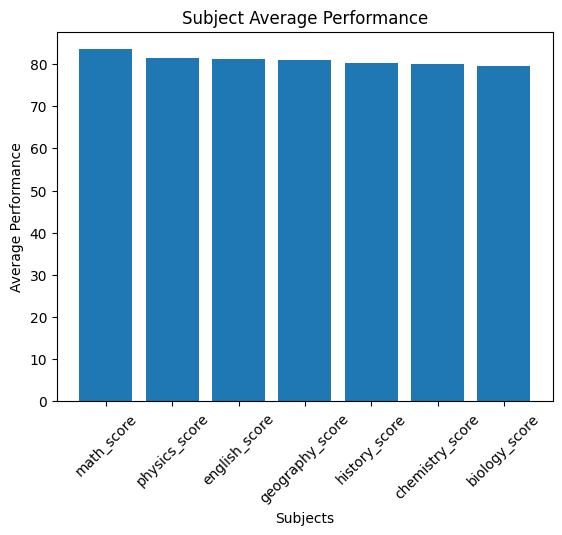

In [39]:
subject_cols = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'geography_score', 'english_score']
subjects_mean = students[subject_cols].mean().sort_values(ascending=False)
display(subjects_mean)
plt.bar(subjects_mean.index, subjects_mean.values)
plt.title("Subject Average Performance")
plt.xlabel('Subjects')
plt.ylabel('Average Performance')
plt.xticks(rotation=45)
plt.show()


##Findings

Mathematics recorded the highest average score among all subjects.
Biology recorded the lowest average score.
The average scores across all subjects were relatively close, indicating that students performed fairly consistently across the curriculum.

##7. Student Demographics
a. What is the gender distribution of the students?

b. How many students have part-time jobs?

c. How many students participate in extracurricular activities?

d. What are the most common career aspirations among the students?

,count
gender,
female,1002
male,998


,count
part_time_job,
False,1684
True,316


,count
extracurricular_activities,
False,1592
True,408


,count
career_aspiration,
Software Engineer,315
Business Owner,309
Unknown,223
Banker,169
Lawyer,138
Accountant,126
Doctor,119
Real Estate Developer,83
Stock Investor,73


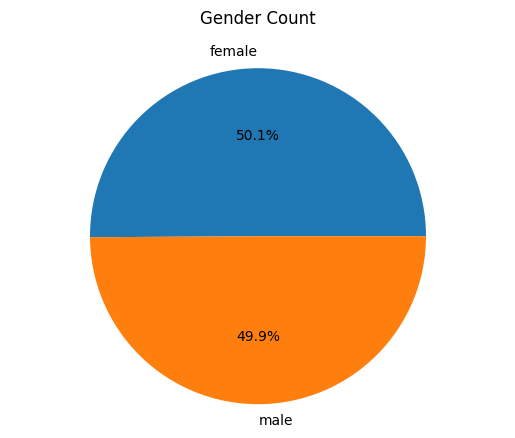

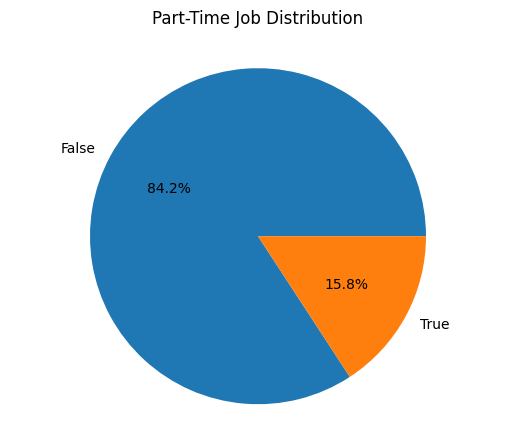

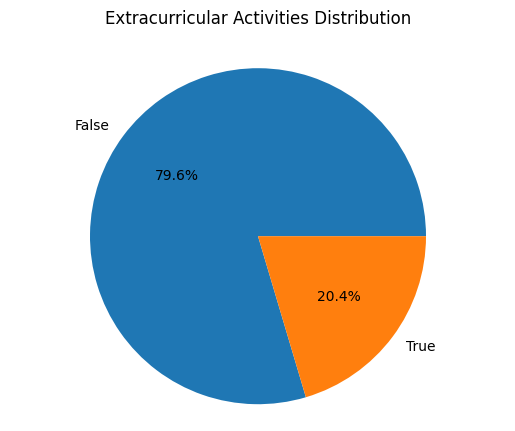

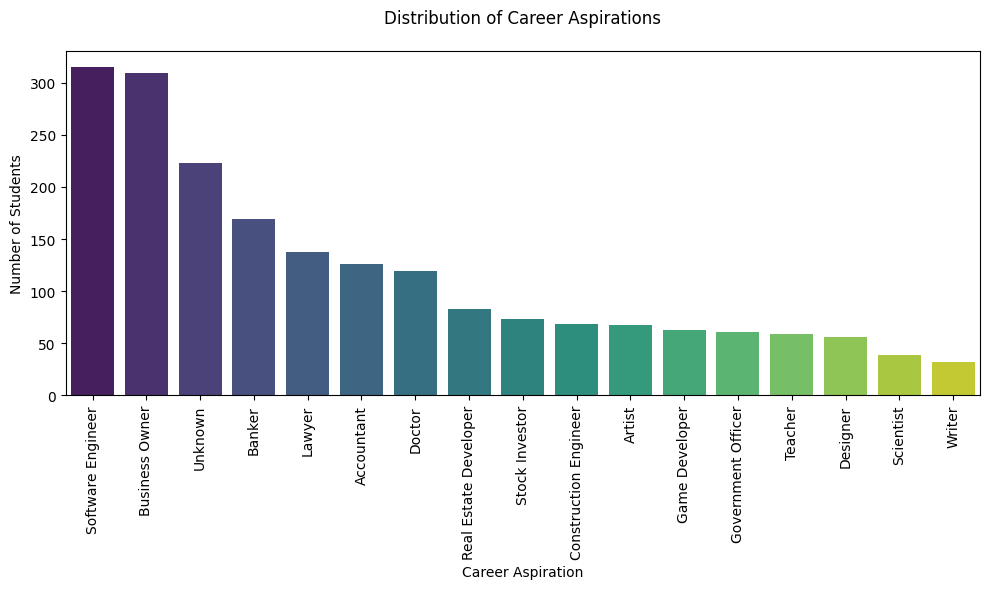

In [40]:
gender_count = students['gender'].value_counts()
display(gender_count)
jobs_counts = students['part_time_job'].value_counts()
display(jobs_counts)
activities_status = students['extracurricular_activities'].value_counts()
display(activities_status)
career_aspirations_counts = students['career_aspiration'].value_counts()
display(career_aspirations_counts)

plt.pie(gender_count.values, labels=gender_count.index, autopct='%1.1f%%')
plt.title("Gender Count", pad=20)
plt.axis('equal')
plt.show()

plt.pie(jobs_counts.values, labels=jobs_counts.index, autopct='%1.1f%%')
plt.title("Part-Time Job Distribution", pad=20)
plt.axis('equal')
plt.show()

plt.pie(activities_status.values, labels=activities_status.index, autopct='%1.1f%%')
plt.title("Extracurricular Activities Distribution", pad=20)
plt.axis('equal')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=career_aspirations_counts.index, y=career_aspirations_counts.values, palette='viridis', hue =career_aspirations_counts.index, legend=False)
plt.title('Distribution of Career Aspirations', pad=20)
plt.xlabel('Career Aspiration')
plt.ylabel('Number of Students')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##Findings
Female students constitute 50.1 percentage of the population while male students constitute the remaining 49.9 percent.

##8. Gender Analysis
a. Which gender performs better across the different subjects?

b. Is there a noticeable difference in academic performance between male and female students?

,Overall_average
gender,
male,81.066991
female,80.894069


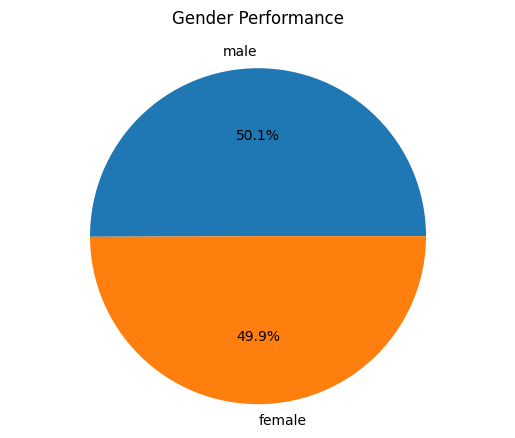

0.10999999999999943


In [41]:
subject_cols = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'geography_score', 'english_score']
students['Overall_average']= students[subject_cols].mean(axis = 1)
gender_average = students.groupby('gender').Overall_average.mean().sort_values(ascending = False)
plt.pie(gender_average.values, labels= gender_average.index, autopct = '%1.1f%%')
display(gender_average)
plt.title('Gender Performance', pad = 20)
plt.axis('equal')
plt.show()
male_mean = 81.0
female_mean = 80.89
difference = male_mean - female_mean
print(difference)

##Findings

Male students have an average performance of 50.1% which is slightly higher than the Female students' average performance of 49.9%.
The difference in academic performance between male and female students is not quite noticeable as there is a difference of 0.10.

##9. Part-Time Job Analysis

a. Do students with part-time jobs perform  differently from those without part-time jobs?

,Overall_average
part_time_job,
False,81.484985
True,78.291139


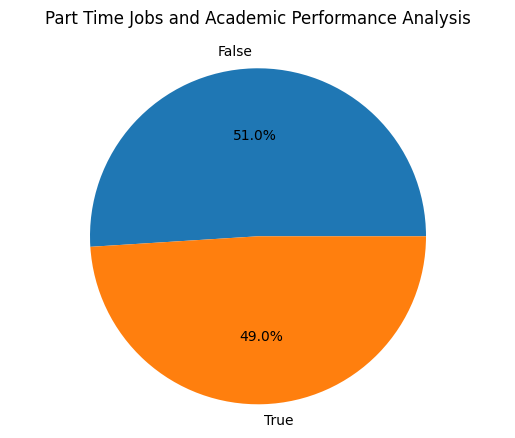

In [42]:
part_time_jobs_analysis = students.groupby('part_time_job').Overall_average.mean()
display(part_time_jobs_analysis)
plt.pie(part_time_jobs_analysis.values, labels=part_time_jobs_analysis.index, autopct = '%1.1f%%')
plt.axis('equal')
plt.title("Part Time Jobs and Academic Performance Analysis", pad=20)
plt.show()

#Findings

Students with a part-time job has an average performance of 49% and Students without a part-time job has an average performance of 51%, indicating that Students without a part-time job tends to perform slightly  better than Students with a part-time job.





##10. Extracurricular Activities Analysis
a. Do students who participate in extracurricular activities perform better academically than those who do not?

,Overall_average
extracurricular_activities,
False,81.078069
True,80.599090


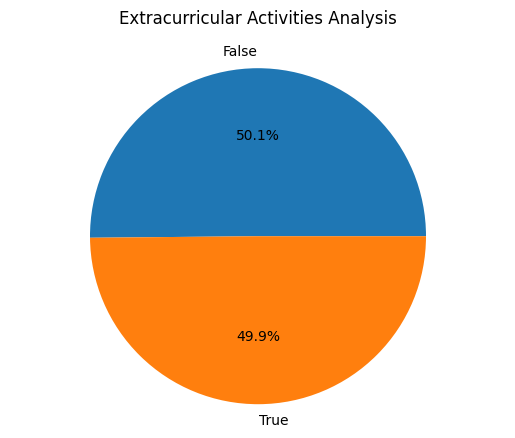

In [43]:
activities = students.groupby("extracurricular_activities").Overall_average.mean()
display(activities)
plt.pie(activities.values, labels = activities.index, autopct = '%1.1f%%')
plt.title('Extracurricular Activities Analysis', pad=20)
plt.axis('equal')
plt.show()

## Findings

Students who participate in extracurricular activities has an overall average performance of 49.9 percentage while students who do not engage in extra curricular activities has an average performance of 50.1 percentage, meaning that the latter performed slightly better than the former. Not a huge difference.

##11. Attendance Analysis

a. Is there a relationship between absence days and academic performance?

,Overall_average
absence_days,
0,81.616725
1,81.673230
2,82.112126
3,82.315051
4,81.078248
5,81.360058
6,78.924370
7,79.296703
8,78.745098


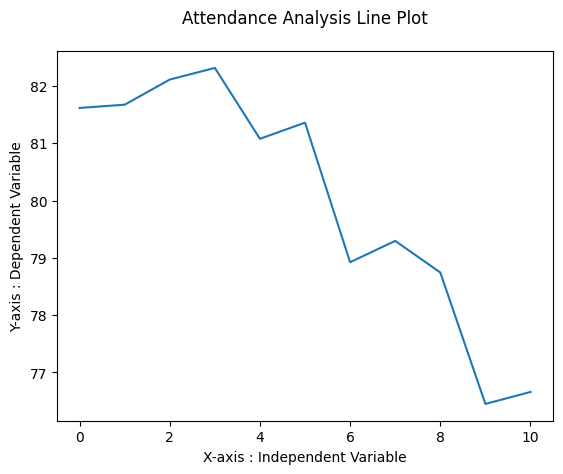

In [44]:
attendance = students.groupby('absence_days').Overall_average.mean().sort_index(ascending=True)
display(attendance)
plt.plot(attendance.index, attendance.values)
plt.title("Attendance Analysis Line Plot", pad=20)
plt.xlabel("X-axis : Independent Variable")
plt.ylabel("Y-axis : Dependent Variable")
plt.show()

##Findings

Students with more absence days tends to achieve lower scores than students with less absence days, though it is not consistent as there are other factors influencing their performance.

##11. Self Study Analysis

a. Do students who spend more hours on self- study better academic performance?

,weekly_self_study_hours,Overall_average
0,0,76.357143
1,1,76.991974
2,2,77.134831
3,3,78.070028
4,4,76.752101
5,5,77.022796
6,6,80.322981
7,7,80.298701
8,8,79.086735
9,9,79.489011


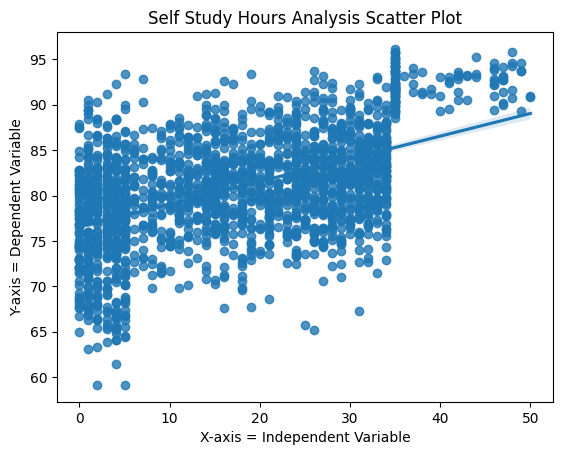

In [45]:
self_study =students.groupby('weekly_self_study_hours').Overall_average.mean().reset_index()
display(self_study)
sns.regplot( x = students["weekly_self_study_hours"], y = students["Overall_average"])
plt.title('Self Study Hours Analysis Scatter Plot')
plt.xlabel('X-axis = Independent Variable')
plt.ylabel('Y-axis = Dependent Variable')
plt.show()

##Findings

Though with little variations, students who spend more hours on self study tends to achieve better academic performance than other students. The scatter plot shows an upward slope and the dots are spread out illustrating that there is a moderate positive correlation between weekly self study hours and academic performance.

##11. Career Aspiration Analysis

a. Which career aspiration has the highest average performance across the different subjects?

b. Does career aspiration appear to be associated with students' academic performance?

,Overall_average
career_aspiration,
Doctor,89.678271
Scientist,86.435897
Lawyer,84.157350
Writer,84.053571
Construction Engineer,83.470588
Designer,82.405612
Software Engineer,82.214966
Banker,81.868977
Game Developer,81.784580


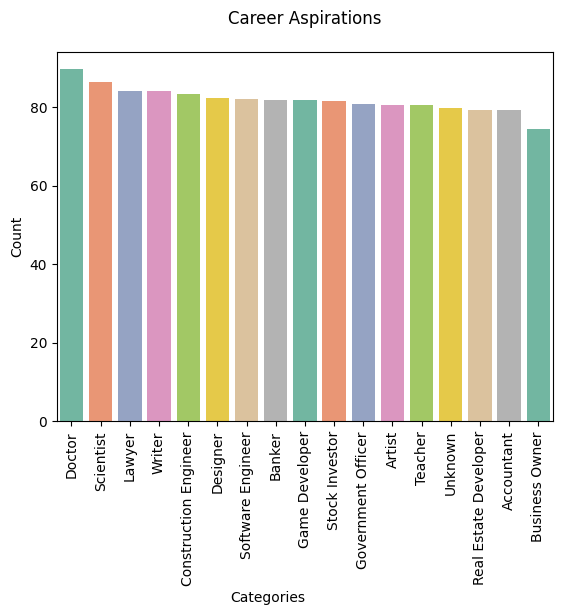

In [46]:
career_performance = students.groupby('career_aspiration').Overall_average.mean().sort_values(ascending=False)
display(career_performance)
sns.barplot(x = career_performance.index, y = career_performance.values, palette = 'Set2', hue = career_performance.index, legend=False)
plt.title('Career Aspirations', pad=20)
plt.xlabel('Categories', ha='right')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

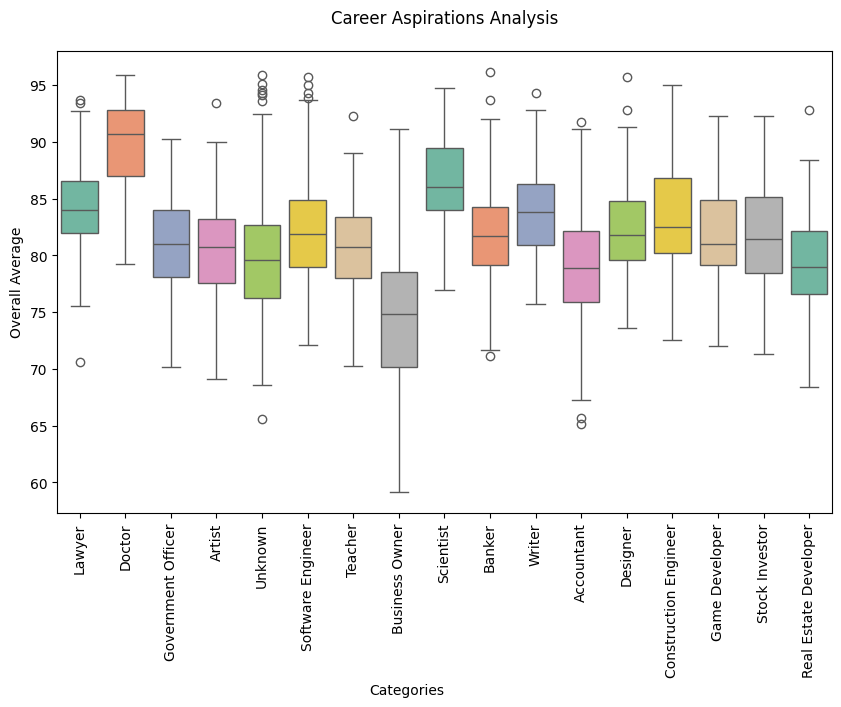

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=students,
    x='career_aspiration',
    y='Overall_average',
    palette='Set2',
    hue = 'career_aspiration',
    legend=False
)
plt.title('Career Aspirations Analysis', pad=20)
plt.xlabel('Categories', ha='right')
plt.ylabel('Overall Average')
plt.xticks(rotation=90)
plt.show()

##Findings

Students aspiring to become Doctors have the highest median overall average, indicating the highest typical academic performance among the career aspiration groups.

Students aspiring to become Business Owners have the lowest median overall average, suggesting the lowest typical academic performance.

The Business Owner category exhibits greater variability in overall average scores, as reflected by its taller box plot.

In contrast, the Doctor category has one of the shortest box plots, indicating relatively consistent academic performance among the middle 50% of students.

Several career aspiration groups contain both high and low outliers, suggesting that a small number of students performed substantially differently from the majority of their peers.

Considerable overlap exists among many of the box plots, indicating that the overall average distributions are broadly similar across several career aspiration groups.

##12. Combined Analysis

a. Does gender and part-time job status together influence students' academic performance?

b. Does gender and extracurricular participation together influence students' academic performance?

c. Does career aspiration and gender influence students' performance across subjects?

In [48]:
display(students.pivot_table(
    values='Overall_average',
    index='gender',
    columns='part_time_job',
    aggfunc='mean'
))

display(students.pivot_table(
    values='Overall_average',
    index= 'gender',
    columns = 'extracurricular_activities',
    aggfunc='mean'
))
display(students.pivot_table(
    values='Overall_average',
    index = 'gender',
    columns = 'career_aspiration',
    aggfunc= 'mean'
))

part_time_job,False,True
gender,,
female,81.354833,78.590248
male,81.612990,77.955896


extracurricular_activities,False,True
gender,,
female,80.998023,80.494824
male,81.157914,80.706468


career_aspiration,Accountant,Artist,Banker,Business Owner,Construction Engineer,Designer,Doctor,Game Developer,Government Officer,Lawyer,Real Estate Developer,Scientist,Software Engineer,Stock Investor,Teacher,Unknown,Writer
gender,,,,,,,,,,,,,,,,,
female,79.408482,81.054422,81.461859,74.783101,NaN,82.674107,89.231806,83.027650,80.820276,84.396104,79.514286,87.744361,82.824721,81.074286,80.605327,79.292267,85.619048
male,78.993088,80.011429,82.504329,74.144828,83.470588,82.047619,90.036797,80.580357,81.033333,83.938492,79.154135,85.192857,81.720854,81.669643,NaN,80.439850,82.040816


##13. Correlation Analysis

a. Is there a relationship between weekly self study hours and students academic performance?

b. Is there a relationship between absence days and students academic performance?

c. Which subjects are most strongly correlated with one another?

d. Which variables show the strongest  positive and negative  correlation?

In [49]:
students.corr(numeric_only=True)

,id,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score,Overall_average
id,1.000000,0.012869,-0.017788,-0.003121,0.008524,-0.014042,0.021959,-0.002003,0.004726,0.045437,-0.001908,-0.005969,0.015612
part_time_job,0.012869,1.000000,0.206361,-0.008382,-0.213963,-0.185573,-0.110774,-0.123929,-0.089219,-0.004072,-0.098809,-0.030352,-0.192846
absence_days,-0.017788,0.206361,1.000000,0.029019,-0.286086,-0.237072,-0.128159,-0.136419,-0.084029,-0.090554,-0.084861,-0.002942,-0.232868
extracurricular_activities,-0.003121,-0.008382,0.029019,1.000000,-0.052515,-0.052968,0.012526,-0.009333,-0.003007,-0.010062,-0.003428,-0.040877,-0.031952
weekly_self_study_hours,0.008524,-0.213963,-0.286086,-0.052515,1.000000,0.393569,0.276231,0.202120,0.201340,0.190481,0.247796,0.153622,0.501520
math_score,-0.014042,-0.185573,-0.237072,-0.052968,0.393569,1.000000,0.147247,0.115719,0.127131,0.081298,0.134831,0.049672,0.508116
history_score,0.021959,-0.110774,-0.128159,0.012526,0.276231,0.147247,1.000000,0.048478,0.121498,0.088502,0.147193,0.065751,0.486900
physics_score,-0.002003,-0.123929,-0.136419,-0.009333,0.202120,0.115719,0.048478,1.000000,0.126163,0.132280,0.054314,0.103126,0.472104
chemistry_score,0.004726,-0.089219,-0.084029,-0.003007,0.201340,0.127131,0.121498,0.126163,1.000000,0.119992,0.068341,0.065430,0.492216
biology_score,0.045437,-0.004072,-0.090554,-0.010062,0.190481,0.081298,0.088502,0.132280,0.119992,1.000000,0.074227,0.106526,0.502391


##Findings

1. Weekly Self-Study Hours ↔ Overall Average (r = 0.502)

Weekly self-study hours showed a moderate positive relationship with the overall average (r = 0.502), suggesting that students who studied for more hours tended to achieve better overall academic performance. These numerical variables show the strongest positive correlation.

2. Absence Days ↔ Overall average  (r = -0.232)

Absence days showed a weak negative relationship with the Overall Average (r = -0.237), indicating that students with more absences tended to achieve better overall academic performance.

3. Part-Time Job ↔ Overall Average (r = -0.193)

Part-time job status showed a weak negative relationship with overall academic performance (r = -0.193), suggesting that students with part-time jobs tended to achieve slightly lower overall academic scores than those without part-time jobs in this dataset. These variables show the most weak negative correlation.

4. Extracurricular Activities ↔ Biology Score (r = -0.010)

Extracurricular activities showed little to no linear relationship with Biology performance (r = -0.010), indicating that participation in extracurricular activities was not meaningfully associated with students' Biology scores in this dataset.

5. Mathematics Score ↔ Physics Score (r = 0.116)

Mathematics score showed a weak positive relationship with Physics score (r = 0.116), suggesting that students who performed well in Mathematics did not necessarily perform equally well in Physics.

6. Weekly Self-Study Hours

Among the explanatory variables, weekly self-study hours exhibited the strongest positive relationship with overall academic performance, making it the variable most closely associated with students' average scores.

7. Absence Days

Absence days showed a consistently negative relationship with students' academic performance across most subjects, suggesting that students with more absences generally tended to achieve lower scores.

8. Subject Relationships

The correlations among individual subject scores were generally weak, indicating that strong performance in one subject did not necessarily correspond to strong performance in another.

9. Extracurricular Activities

Participation in extracurricular activities exhibited little to no meaningful relationship with students' academic performance in this dataset.

##Conclusion

Key Findings

This exploratory data analysis examined the academic performance of 2000 students across seven subjects using demographic, behavioural and academic variables.
The following key findings emerged from the analysis:

Study Habits: Weekly self-study hours showed the strongest positive relationship with overall academic performance (r = 0.502). Students who dedicated more time to self-study consistently achieved higher scores across all subjects.

Attendance: Absence days showed a negative relationship with academic performance. Students with more absences generally tended to achieve lower scores, suggesting that regular attendance contributes positively to academic achievement.

Part-Time Employment: Students with part-time jobs recorded a slightly lower overall average (78.29) compared to students without part-time jobs (81.48), suggesting that employment may affect academic focus.

Gender: The difference in academic performance between male and female students was minimal (0.10), indicating that gender has little influence on academic achievement in this dataset.

Subject Performance: Mathematics recorded the highest average score (83.45) while Biology recorded the lowest (79.58). However scores across all subjects were relatively close, indicating consistent performance across the curriculum.

Career Aspiration: Students aspiring to become Doctors recorded the highest overall average (89.68) while Business Owners recorded the lowest (74.48).

Recommendations

Students should prioritise consistent attendance and dedicated self-study time as these factors showed the strongest association with academic success.

Limitations

This analysis is observational. The relationships identified do not imply causation. Additional factors not captured in this dataset may influence student performance.

In [50]:
students.to_csv('grade_analysis.csv')